# CAD Retrieval — Ablation Study

**Project:** SWL2026 — Unsupervised GNN-Based CAD Part Retrieval
**Dataset:** MFCAD (15,488 processed graphs, 16 machining feature classes)
**Author:** Eduardo

---

## What this notebook does

This notebook evaluates **12 trained model configurations** across **five independent ablations**, each isolating exactly one design choice while holding everything else fixed:

| Ablation | What's tested | Configs |
|---|---|---|
| Embedding dimension | Size of the final CAD-part vector | 32, 64 (baseline), 128, 256 |
| Temperature (τ) | Strictness of the contrastive loss | 0.05, 0.1 (baseline), 0.5 |
| Pooling strategy | How face-level vectors combine into one part vector | mean (baseline), max, max+mean |
| Augmentation mode | Which perturbations create contrastive training pairs | both (baseline), edge_drop only, feature_noise only |
| Layer count | Number of GINE message-passing rounds | 2, 3 (baseline), 5 |

**Methodology note (single-variable rule):** every config in every ablation was trained for an identical **30 epochs**, on the identical dataset, with identical batch size — the *only* thing that ever differs between rows in the same ablation block is the one parameter being tested. This is what makes the comparisons below valid: any difference in the resulting metrics can be attributed to that one parameter, not to incidental differences in training conditions.

The `baseline_dim64_temp01` config (out_dim=64, temp=0.1, pooling=mean, aug_mode=both, num_layers=3) is shared across all five ablations as the common reference point.

## 1. Setup

Imports and paths. This notebook assumes it's run from the `notebooks/` directory of the repo, with all 12 checkpoints already trained and their FAISS databases already built (see `run_*_sweep.ps1` and `build_*_databases.ps1` scripts in the repo root).

In [2]:
import pickle
import numpy as np
import faiss
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

PROJECT_ROOT = Path("..")
LABEL_DIR = PROJECT_ROOT / "data" / "raw_step" / "mfcad_label"
SWEEP_DIR = PROJECT_ROOT / "checkpoints" / "sweep"

NUM_CLASSES = 16
MATCH_THRESHOLD = 0.95
K_MAX = 10

print(f"Label directory exists: {LABEL_DIR.exists()}")
print(f"Sweep directory exists: {SWEEP_DIR.exists()}")

Label directory exists: True
Sweep directory exists: True


## 2. Configuration registry

The 12 configs evaluated, organized by which ablation they belong to. Each entry records every setting the config was trained with — not just the one being varied — so the table at the end is fully self-documenting.

In [3]:
CONFIGS = [
    # --- Embedding dimension ablation (temp, pooling, aug, layers fixed) ---
    {"name": "dim32",                 "out_dim": 32,  "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "dimension"},
    {"name": "baseline_dim64_temp01", "out_dim": 64,  "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "dimension"},
    {"name": "dim128",                "out_dim": 128, "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "dimension"},
    {"name": "dim256",                "out_dim": 256, "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "dimension"},

    # --- Temperature ablation (out_dim, pooling, aug, layers fixed) ---
    {"name": "temp005",               "out_dim": 64,  "temp": 0.05, "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "temperature"},
    {"name": "temp05",                "out_dim": 64,  "temp": 0.5,  "pooling": "mean", "aug_mode": "both", "num_layers": 3, "ablation": "temperature"},

    # --- Pooling ablation (out_dim, temp, aug, layers fixed) ---
    {"name": "pooling_max",           "out_dim": 64,  "temp": 0.1,  "pooling": "max",      "aug_mode": "both", "num_layers": 3, "ablation": "pooling"},
    {"name": "pooling_max_mean",      "out_dim": 64,  "temp": 0.1,  "pooling": "max_mean", "aug_mode": "both", "num_layers": 3, "ablation": "pooling"},

    # --- Augmentation ablation (out_dim, temp, pooling, layers fixed) ---
    {"name": "aug_edge_drop",         "out_dim": 64,  "temp": 0.1,  "pooling": "mean", "aug_mode": "edge_drop",     "num_layers": 3, "ablation": "augmentation"},
    {"name": "aug_feature_noise",     "out_dim": 64,  "temp": 0.1,  "pooling": "mean", "aug_mode": "feature_noise", "num_layers": 3, "ablation": "augmentation"},

    # --- Layer count ablation (out_dim, temp, pooling, aug fixed) ---
    {"name": "layers2",               "out_dim": 64,  "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 2, "ablation": "layers"},
    {"name": "layers5",               "out_dim": 64,  "temp": 0.1,  "pooling": "mean", "aug_mode": "both", "num_layers": 5, "ablation": "layers"},
]

# baseline_dim64_temp01 doubles as the "temp=0.1", "pooling=mean", "aug=both",
# and "layers=3" reference point for every other ablation block too -- it is
# listed once above (under "dimension") and reused conceptually below.
print(f"{len(CONFIGS)} configs registered.")

12 configs registered.


## 3. Evaluation methodology

Retrieval quality can't be judged by class labels alone -- MFCAD's labels are *per-face* feature-type annotations, not a single "this CAD part belongs to category X" label. So "is retrieved part B a good match for query part A?" is answered with a **manufacturing-aware proxy**:

1. For each CAD model, build a 16-dimensional histogram counting how many faces belong to each of the 16 machining feature classes (e.g., "3 planar faces, 2 fillets, 1 pocket...").
2. Two models are considered a **match** if the cosine similarity between their histograms is **≥ 0.95** -- i.e., they have a very similar *distribution* of machining features, even if not byte-identical.
3. For each of the 15,488 graphs, query its trained embedding against the FAISS index (built from the same model), retrieve the top 10 nearest neighbors (excluding itself), and check whether any of them are a "match" by the histogram rule above.

This gives four metrics per config:
- **Recall@1 / @5 / @10** -- the fraction of queries where a true match appears in the top 1 / 5 / 10 retrieved results
- **MRR** (Mean Reciprocal Rank) -- on average, how early the first true match appears in the ranking (1/rank, averaged across all queries)

In [4]:
def cosine_sim(v1, v2):
    norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return np.dot(v1, v2) / (norm1 * norm2)


def build_label_signatures(metadata):
    """Builds the 16-D feature histogram + validity mask for each model name."""
    signatures = []
    valid_mask = []

    for meta in metadata:
        base_name = meta.replace(".step", "")
        label_path = LABEL_DIR / f"{base_name}.face_truth"

        if label_path.exists():
            with open(label_path, "rb") as file:
                face_labels = pickle.load(file)

            labels = face_labels.values() if isinstance(face_labels, dict) else face_labels

            hist = np.zeros(NUM_CLASSES)
            for lbl in labels:
                if 0 <= lbl < NUM_CLASSES:
                    hist[lbl] += 1

            signatures.append(hist)
            valid_mask.append(True)
        else:
            signatures.append(np.zeros(NUM_CLASSES))
            valid_mask.append(False)

    return np.array(signatures), valid_mask


def evaluate_config(cfg):
    save_dir = SWEEP_DIR / cfg["name"]
    index_path = save_dir / "faiss_index.bin"
    metadata_path = save_dir / "metadata.pkl"

    if not index_path.exists() or not metadata_path.exists():
        name = cfg["name"]
        print(f"[SKIP] {name}: missing faiss_index.bin or metadata.pkl")
        return None

    with open(metadata_path, "rb") as f:
        metadata = pickle.load(f)

    index = faiss.read_index(str(index_path))
    num_vectors = index.ntotal
    vectors = np.array([index.reconstruct(i) for i in range(num_vectors)])

    signatures, valid_mask = build_label_signatures(metadata)

    distances, indices = index.search(vectors, K_MAX + 1)

    recalls = {1: 0, 5: 0, 10: 0}
    mrr = 0.0
    valid_queries = 0
    config_name = cfg["name"]

    for i in tqdm(range(num_vectors), desc=f"Evaluating {config_name}", leave=False):
        if not valid_mask[i]:
            continue

        query_sig = signatures[i]
        if np.linalg.norm(query_sig) == 0:
            continue

        valid_queries += 1
        retrieved_idx = indices[i][1:]  # exclude the query itself

        is_relevant = []
        for idx in retrieved_idx:
            if not valid_mask[idx]:
                is_relevant.append(False)
            else:
                sim = cosine_sim(query_sig, signatures[idx])
                is_relevant.append(sim >= MATCH_THRESHOLD)

        for k in recalls.keys():
            if any(is_relevant[:k]):
                recalls[k] += 1

        for rank, relevant in enumerate(is_relevant):
            if relevant:
                mrr += 1.0 / (rank + 1)
                break

    if valid_queries == 0:
        print(f"[WARNING] {config_name}: valid_queries == 0, cannot compute metrics")
        return None

    for k in recalls.keys():
        recalls[k] /= valid_queries
    mrr /= valid_queries

    return {
        **cfg,
        "valid_queries": valid_queries,
        "recall@1": recalls[1] * 100,
        "recall@5": recalls[5] * 100,
        "recall@10": recalls[10] * 100,
        "mrr": mrr,
    }

## 4. Run the evaluation

This evaluates all 12 configs live, from their saved checkpoints and FAISS indexes. Takes roughly 1-2 minutes total on CPU.

In [5]:
results = []
for cfg in CONFIGS:
    result = evaluate_config(cfg)
    if result is not None:
        results.append(result)
        name = result["name"]
        print(
            f"[OK] {name:24s} "
            f"R@1={result['recall@1']:6.2f}%  "
            f"R@5={result['recall@5']:6.2f}%  "
            f"R@10={result['recall@10']:6.2f}%  "
            f"MRR={result['mrr']:.4f}  "
            f"(valid_queries={result['valid_queries']})"
        )

print(f"\n{len(results)}/{len(CONFIGS)} configs evaluated successfully.")

Evaluating dim32:   0%|          | 0/15488 [00:00<?, ?it/s]

[OK] dim32                    R@1= 11.59%  R@5= 30.05%  R@10= 41.15%  MRR=0.1959  (valid_queries=15488)


Evaluating baseline_dim64_temp01:   0%|          | 0/15488 [00:00<?, ?it/s]

[OK] baseline_dim64_temp01    R@1= 12.25%  R@5= 31.31%  R@10= 42.74%  MRR=0.2043  (valid_queries=15488)


Evaluating dim128:   0%|          | 0/15488 [00:00<?, ?it/s]

...

[OK] aug_feature_noise        R@1= 11.27%  R@5= 28.53%  R@10= 38.78%  MRR=0.1876  (valid_queries=15488)


Evaluating layers2:   0%|          | 0/15488 [00:00<?, ?it/s]

[OK] layers2                  R@1= 12.00%  R@5= 30.51%  R@10= 41.74%  MRR=0.1997  (valid_queries=15488)


Evaluating layers5:   0%|          | 0/15488 [00:00<?, ?it/s]

[OK] layers5                  R@1= 12.34%  R@5= 31.43%  R@10= 42.70%  MRR=0.2059  (valid_queries=15488)

12/12 configs evaluated successfully.


## 5. Results table

All 12 configs, side by side.

In [6]:
import pandas as pd

df = pd.DataFrame(results)
df = df[["ablation", "name", "out_dim", "temp", "pooling", "aug_mode", "num_layers", "recall@1", "recall@5", "recall@10", "mrr"]]
df.columns = ["Ablation", "Config", "out_dim", "temp", "pooling", "aug_mode", "layers", "Recall@1 (%)", "Recall@5 (%)", "Recall@10 (%)", "MRR"]
df = df.round(2)
df

,Ablation,Config,out_dim,temp,pooling,aug_mode,layers,Recall@1 (%),Recall@5 (%),Recall@10 (%),MRR
0,dimension,dim32,32,0.10,mean,both,3,11.59,30.05,41.15,0.20
1,dimension,baseline_dim64_temp01,64,0.10,mean,both,3,12.25,31.31,42.74,0.20
2,dimension,dim128,128,0.10,mean,both,3,12.45,31.68,42.88,0.21
3,dimension,dim256,256,0.10,mean,both,3,12.69,32.15,44.20,0.21
4,temperature,temp005,64,0.05,mean,both,3,11.23,29.82,41.40,0.19
5,temperature,temp05,64,0.50,mean,both,3,9.48,27.56,39.09,0.17
6,pooling,pooling_max,64,0.10,max,both,3,11.32,29.91,42.52,0.20
7,pooling,pooling_max_mean,64,0.10,max_mean,both,3,12.25,31.84,42.96,0.21
8,augmentation,aug_edge_drop,64,0.10,mean,edge_drop,3,12.22,31.04,42.59,0.20
9,augmentation,aug_feature_noise,64,0.10,mean,feature_noise,3,11.27,28.53,38.78,0.19


## 6. Interpretation

### 6.1 Embedding dimension

Recall@1, Recall@5, Recall@10, and MRR all **increase monotonically** from 32 → 256 dimensions, with no sign of saturation at the largest size tested. This suggests the model has not yet run out of useful "room" to encode distinguishing shape information -- if compute allowed, it would be worth testing whether 512 dimensions continues the trend or finally plateaus.

### 6.2 Temperature (τ)

Performance follows a clear **inverted-U**: τ=0.1 (the original default) outperforms both a sharper setting (τ=0.05) and a softer setting (τ=0.5) on every metric, with τ=0.5 producing the largest single drop observed in this study. Too sharp a temperature appears to over-penalize near-misses between legitimately similar parts; too soft a temperature fails to push dissimilar parts apart strongly enough.

### 6.3 Pooling strategy

Pure **max pooling underperforms** mean pooling on every metric -- discarding the "average shape" signal in favor of only the single most extreme per-dimension value loses real information. **max + mean concatenated** is the best performer in this ablation, edging out plain mean on every metric, consistent with the idea that giving the model both "most distinctive feature" and "overall shape" signals simultaneously is strictly more informative than either alone. The improvement is modest (roughly 0.5-1.5 percentage points) and, with only one trained run per config, should be read as a real *direction* rather than a precisely pinned-down *magnitude*.

### 6.4 Augmentation mode

This ablation produced the most informative result of the five. **Edge-dropout alone nearly matches** the combined "both" baseline on every metric, suggesting edge dropout is doing nearly all of the useful work in the original augmentation strategy. **Feature-noise alone is the weakest configuration in the entire 12-config study**, despite reaching the *lowest training loss* of any run -- a textbook case of the contrastive task becoming too easy: jittering face measurements without disturbing graph topology makes the two augmented views trivially distinguishable from other parts, so the model "solves" the task without learning generalizable shape structure.

### 6.5 Layer count

Performance improves from 2→3 layers, then **flattens** going from 3→5 layers (Recall@10 even dips very slightly at 5 layers). This is consistent with the original choice of `num_layers=3` already being close to optimal for this dataset and architecture -- further depth offers diminishing returns. As with the pooling result, the tiny 3→5 difference is within plausible single-run noise and shouldn't be over-interpreted as a confirmed decline.

### A note on scientific honesty

Every comparison above is valid in *direction* because of the single-variable rule (identical epochs, dataset, and all other settings within each ablation block). None of these results come from repeated trials, however -- each config was trained exactly once. Small differences (under roughly 1 percentage point) should be treated as suggestive rather than conclusive; the large, consistent effects (temperature's inverted-U, feature-noise's underperformance, dimension's monotonic climb) are far more trustworthy than the small ones (pooling's modest edge, layers' tiny 3→5 dip).

## 7. Charts

Static versions of each ablation, for use in reports or presentations.

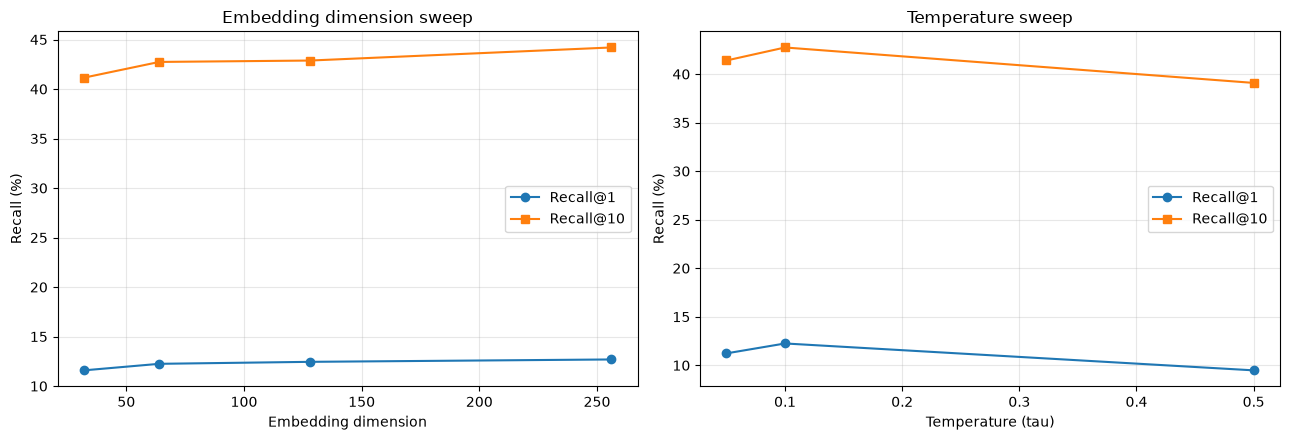

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

dim_df = df[df["Ablation"] == "dimension"].sort_values("out_dim")
ax = axes[0]
ax.plot(dim_df["out_dim"], dim_df["Recall@1 (%)"], marker="o", label="Recall@1")
ax.plot(dim_df["out_dim"], dim_df["Recall@10 (%)"], marker="s", label="Recall@10")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Recall (%)")
ax.set_title("Embedding dimension sweep")
ax.legend()
ax.grid(alpha=0.3)

temp_df = pd.concat([
    df[df["Ablation"] == "temperature"],
    df[df["Config"] == "baseline_dim64_temp01"]
]).sort_values("temp")
ax = axes[1]
ax.plot(temp_df["temp"], temp_df["Recall@1 (%)"], marker="o", label="Recall@1")
ax.plot(temp_df["temp"], temp_df["Recall@10 (%)"], marker="s", label="Recall@10")
ax.set_xlabel("Temperature (tau)")
ax.set_ylabel("Recall (%)")
ax.set_title("Temperature sweep")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

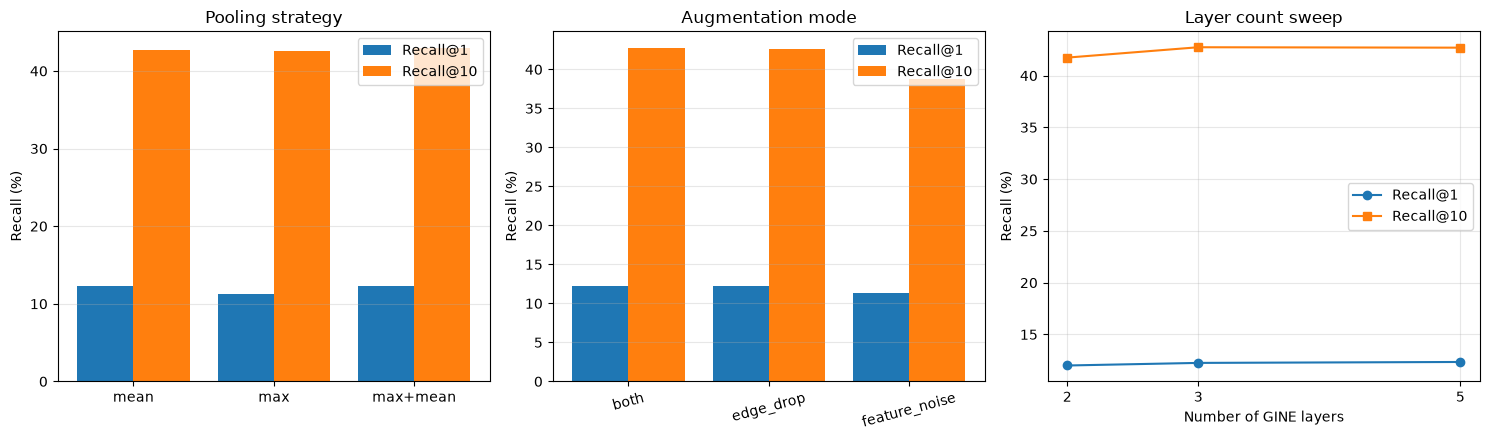

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pool_df = pd.concat([
    df[df["Config"] == "baseline_dim64_temp01"],
    df[df["Ablation"] == "pooling"]
])
pool_order = ["baseline_dim64_temp01", "pooling_max", "pooling_max_mean"]
pool_df = pool_df.set_index("Config").loc[pool_order].reset_index()
ax = axes[0]
x = np.arange(len(pool_df))
ax.bar(x - 0.2, pool_df["Recall@1 (%)"], width=0.4, label="Recall@1")
ax.bar(x + 0.2, pool_df["Recall@10 (%)"], width=0.4, label="Recall@10")
ax.set_xticks(x)
ax.set_xticklabels(["mean", "max", "max+mean"])
ax.set_ylabel("Recall (%)")
ax.set_title("Pooling strategy")
ax.legend()
ax.grid(alpha=0.3, axis="y")

aug_df = pd.concat([
    df[df["Config"] == "baseline_dim64_temp01"],
    df[df["Ablation"] == "augmentation"]
])
aug_order = ["baseline_dim64_temp01", "aug_edge_drop", "aug_feature_noise"]
aug_df = aug_df.set_index("Config").loc[aug_order].reset_index()
ax = axes[1]
x = np.arange(len(aug_df))
ax.bar(x - 0.2, aug_df["Recall@1 (%)"], width=0.4, label="Recall@1")
ax.bar(x + 0.2, aug_df["Recall@10 (%)"], width=0.4, label="Recall@10")
ax.set_xticks(x)
ax.set_xticklabels(["both", "edge_drop", "feature_noise"], rotation=15)
ax.set_ylabel("Recall (%)")
ax.set_title("Augmentation mode")
ax.legend()
ax.grid(alpha=0.3, axis="y")

layers_df = pd.concat([
    df[df["Config"] == "baseline_dim64_temp01"],
    df[df["Ablation"] == "layers"]
]).sort_values("layers")
ax = axes[2]
ax.plot(layers_df["layers"], layers_df["Recall@1 (%)"], marker="o", label="Recall@1")
ax.plot(layers_df["layers"], layers_df["Recall@10 (%)"], marker="s", label="Recall@10")
ax.set_xlabel("Number of GINE layers")
ax.set_ylabel("Recall (%)")
ax.set_title("Layer count sweep")
ax.set_xticks([2, 3, 5])
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Remaining work

This notebook covers five ablations on the MFCAD dataset. Not yet covered:

- **Feature-level ablation** (zeroing `surf_idx`, `area`, `curve_idx` columns in the input graphs) -- planned via a post-hoc PyG transform on existing `.pt` files, avoiding the `pythonocc-core` / ARM64 environment blocker.
- **Fusion360 Gallery evaluation** -- `extract_fusion360.py` is complete, but no corresponding evaluation notebook exists yet for that dataset.